In [7]:
from google.colab import files

files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"dhanujgoyal","key":"e75f739f9c8d1fc44b50d416d6744269"}'}

In [8]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [9]:
!kaggle datasets list -s cats dogs

usage: kaggle [-h] [-v] [-W]
              {competitions,c,datasets,d,kernels,k,models,m,files,f,benchmarks,b,config,auth}
              ...
kaggle: error: unrecognized arguments: dogs


In [10]:
!kaggle datasets download -d tongpython/cat-and-dog

Dataset URL: https://www.kaggle.com/datasets/tongpython/cat-and-dog
License(s): CC0-1.0
100% 218M/218M [00:00<00:00, 242MB/s]



In [11]:
!unzip -q cat-and-dog.zip

In [12]:
import os

for root, dirs, files in os.walk('/content'):
    if len(files) > 0:
        print(root)

/content
/content/.config
/content/.config/logs/2026.06.04
/content/.config/configurations
/content/training_set/training_set/dogs
/content/training_set/training_set/cats
/content/test_set/test_set/dogs
/content/test_set/test_set/cats
/content/sample_data


In [13]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
import matplotlib.pyplot as plt

In [14]:
train_dir = "/content/training_set/training_set"
test_dir = "/content/test_set/test_set"

In [15]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [16]:
training_set = train_datagen.flow_from_directory(
    train_dir,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary'
)

test_set = test_datagen.flow_from_directory(
    test_dir,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary'
)

Found 8005 images belonging to 2 classes.
Found 2023 images belonging to 2 classes.


In [17]:
cnn = Sequential()

cnn.add(Conv2D(
    filters=32,
    kernel_size=3,
    activation='relu',
    input_shape=(128,128,3)
))

cnn.add(MaxPooling2D(pool_size=2))

cnn.add(Conv2D(
    filters=64,
    kernel_size=3,
    activation='relu'
))

cnn.add(MaxPooling2D(pool_size=2))

cnn.add(Conv2D(
    filters=128,
    kernel_size=3,
    activation='relu'
))

cnn.add(MaxPooling2D(pool_size=2))

cnn.add(Flatten())

cnn.add(Dense(
    units=128,
    activation='relu'
))

cnn.add(Dropout(0.5))

cnn.add(Dense(
    units=1,
    activation='sigmoid'
))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
cnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [19]:
history = cnn.fit(
    training_set,
    validation_data=test_set,
    epochs=10
)

Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 333s 1s/step - accuracy: 0.5452 - loss: 0.6879 - val_accuracy: 0.6288 - val_loss: 0.6598
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 319s 1s/step - accuracy: 0.6433 - loss: 0.6397 - val_accuracy: 0.6930 - val_loss: 0.5938
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 325s 1s/step - accuracy: 0.6951 - loss: 0.5851 - val_accuracy: 0.7360 - val_loss: 0.5447
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 319s 1s/step - accuracy: 0.7284 - loss: 0.5441 - val_accuracy: 0.7578 - val_loss: 0.5150
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 327s 1s/step - accuracy: 0.7528 - loss: 0.5065 - val_accuracy: 0.7677 - val_loss: 0.4850
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 319s 1s/step - accuracy: 0.7720 - loss: 0.4785 - val_accuracy: 0.7790 - val_loss: 0.4627
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 326s 1s/step - accuracy: 0.7894 - loss: 0.4503 - val_accuracy: 0.7835 - val_loss: 0.4554
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 321s 1s/step - accuracy: 0.8065 - loss: 0.4239 - val_accu

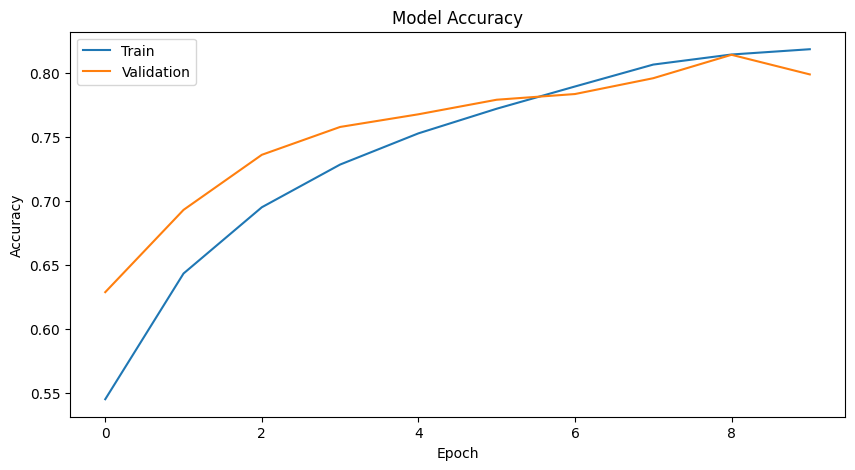

In [20]:
plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

plt.show()

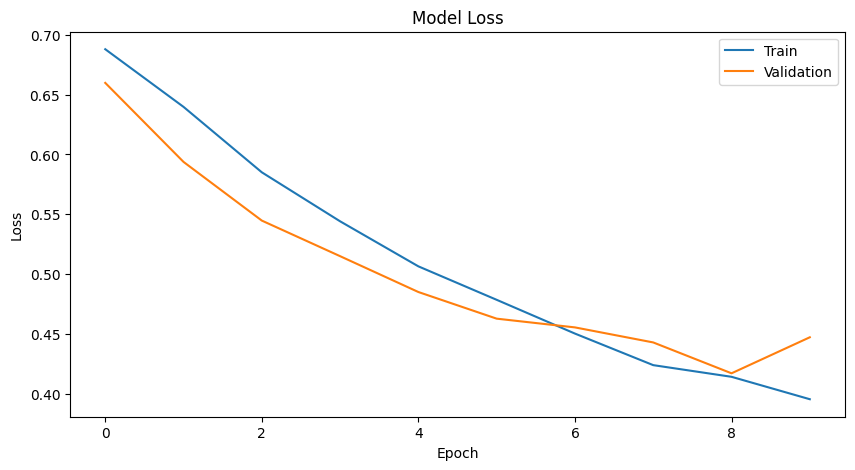

In [21]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])

plt.show()

In [22]:
loss, accuracy = cnn.evaluate(test_set)

print("Test Accuracy:", accuracy*100)

64/64 ━━━━━━━━━━━━━━━━━━━━ 22s 336ms/step - accuracy: 0.7988 - loss: 0.4472
Test Accuracy: 79.88136410713196


In [ ]:
cnn.save("cats_dogs_cnn.h5")

In [27]:
from google.colab import files

uploaded = files.upload()

Saving cat.jpg to cat.jpg


In [28]:
import os

print(os.listdir('/content'))

['.config', 'training_set', 'test_set', 'cat.png', 'cat.jpg', 'cat-and-dog.zip', 'kaggle.json', 'sample_data']


In [29]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = "/content/cat.jpg"   # apni image ka naam

img = image.load_img(
    img_path,
    target_size=(128,128)
)

img_array = image.img_to_array(img)

img_array = np.expand_dims(
    img_array,
    axis=0
)

img_array = img_array / 255.0

prediction = cnn.predict(img_array)

print("Raw Prediction:", prediction)

if prediction[0][0] > 0.5:
    print("🐶 Dog")
else:
    print("🐱 Cat")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step
Raw Prediction: [[0.91790545]]
🐶 Dog


In [30]:
print(training_set.class_indices)

{'cats': 0, 'dogs': 1}


In [31]:
print(training_set.class_indices)

pred = cnn.predict(img_array)

print("Prediction Value =", pred[0][0])

{'cats': 0, 'dogs': 1}
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Prediction Value = 0.91790545


In [32]:
loss, acc = cnn.evaluate(test_set)

print("Accuracy =", acc*100)

64/64 ━━━━━━━━━━━━━━━━━━━━ 20s 317ms/step - accuracy: 0.7988 - loss: 0.4472
Accuracy = 79.88136410713196


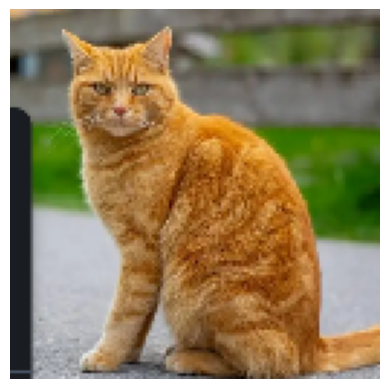

In [33]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

img = image.load_img(img_path, target_size=(128,128))

plt.imshow(img)
plt.axis('off')
plt.show()

In [34]:
import os
import random
from tensorflow.keras.preprocessing import image
import numpy as np

cat_folder = "/content/test_set/test_set/cats"
dog_folder = "/content/test_set/test_set/dogs"

for i in range(5):

    img_name = random.choice(os.listdir(cat_folder))
    path = os.path.join(cat_folder, img_name)

    img = image.load_img(path, target_size=(128,128))
    img_array = image.img_to_array(img)/255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = cnn.predict(img_array, verbose=0)

    print(f"Actual: CAT | Prediction: {pred[0][0]:.4f}")

Actual: CAT | Prediction: 0.0245
Actual: CAT | Prediction: 0.2411
Actual: CAT | Prediction: 0.0073
Actual: CAT | Prediction: 0.1050
Actual: CAT | Prediction: 0.4414


In [35]:
for i in range(5):

    img_name = random.choice(os.listdir(dog_folder))
    path = os.path.join(dog_folder, img_name)

    img = image.load_img(path, target_size=(128,128))
    img_array = image.img_to_array(img)/255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = cnn.predict(img_array, verbose=0)

    print(f"Actual: DOG | Prediction: {pred[0][0]:.4f}")

Actual: DOG | Prediction: 0.8475
Actual: DOG | Prediction: 0.8535
Actual: DOG | Prediction: 0.8084
Actual: DOG | Prediction: 0.9602
Actual: DOG | Prediction: 0.4868


In [36]:
loss, acc = cnn.evaluate(test_set)

print("Test Accuracy:", acc*100)

64/64 ━━━━━━━━━━━━━━━━━━━━ 22s 338ms/step - accuracy: 0.7988 - loss: 0.4472
Test Accuracy: 79.88136410713196


In [37]:
import os
import random
from tensorflow.keras.preprocessing import image
import numpy as np

cat_folder = "/content/test_set/test_set/cats"

for i in range(5):

    img_name = random.choice(os.listdir(cat_folder))
    path = os.path.join(cat_folder, img_name)

    img = image.load_img(path, target_size=(128,128))
    img_array = image.img_to_array(img)/255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = cnn.predict(img_array, verbose=0)

    print(img_name, pred[0][0])

cat.4192.jpg 0.87043536
cat.4411.jpg 0.044229653
cat.4981.jpg 0.0061399024
cat.4977.jpg 0.18588106
cat.4035.jpg 0.021994924
